# 06. Interference and Spillovers

Most causal inference begins with a simplifying assumption:

> One unit's outcome depends only on that unit's own treatment.

That assumption is often false in industry.

A seller's ranking treatment affects other sellers. A customer coupon changes what friends buy. A fraud model intervention changes attacker behavior. A sales enablement program changes team norms. A marketplace feature can reallocate attention rather than create new demand.

This notebook studies causal inference when treatment spills across units. We will move from the no-interference assumption to partial interference, direct and indirect effects, randomized saturation designs, network exposure mappings, graph-cluster randomization, and marketplace equilibrium effects.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain the no-interference part of SUTVA.
- Recognize common interference patterns in product, marketplace, health, education, and operations settings.
- Distinguish direct, indirect, total, and overall effects under partial interference.
- Explain why individual randomization can estimate the wrong policy effect when spillovers exist.
- Use cluster randomization and randomized saturation designs to learn about spillovers.
- Define exposure mappings for network experiments.
- Diagnose when a network or marketplace experiment is likely contaminated by spillovers.
- Write an industry experiment memo when interference is plausible.


## 1. Setup

We will use pandas, numpy, statsmodels, seaborn, matplotlib, Graphviz, and networkx.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def mean_difference(df, outcome, treatment):
    treated = df.loc[df[treatment] == 1, outcome]
    control = df.loc[df[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


## 2. The No-Interference Assumption

In the standard potential outcomes setup, unit $i$ has potential outcomes:

$$
Y_i(1), \quad Y_i(0)
$$

This notation hides a strong assumption: unit $i$'s outcome depends only on $A_i$, not on the assignments of other units.

With possible interference, the potential outcome is:

$$
Y_i(A_1, A_2, \dots, A_n)
$$

The number of potential outcomes explodes because each unit may respond to the full assignment vector.


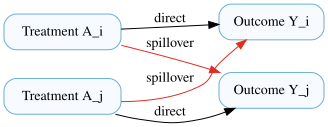

In [2]:
dot = Digraph("interference_dag", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("A_i", "Treatment A_i")
dot.node("Y_i", "Outcome Y_i")
dot.node("A_j", "Treatment A_j")
dot.node("Y_j", "Outcome Y_j")

dot.edge("A_i", "Y_i", label="direct")
dot.edge("A_j", "Y_j", label="direct")
dot.edge("A_j", "Y_i", color="#de2d26", label="spillover")
dot.edge("A_i", "Y_j", color="#de2d26", label="spillover")

dot


Rubin's stable unit treatment value assumption includes the idea that there is no interference between units and no hidden versions of treatment. Hudgens and Halloran (2008) develop causal estimands under partial interference, where interference is allowed within groups but not across groups. Aronow and Samii (2017) provide a randomization-based framework for general interference using exposure mappings.


## 3. Industry Examples of Interference

Interference is not rare. It is often the default in connected systems.


In [3]:
examples = pd.DataFrame(
    [
        {
            "domain": "Marketplace ranking",
            "unit": "Seller or listing",
            "spillover path": "Boosting one listing changes impressions and purchases for nearby listings.",
            "risk": "A listing-level A/B test may estimate reallocation, not market expansion.",
        },
        {
            "domain": "Social product",
            "unit": "User",
            "spillover path": "Treated users invite, message, or influence untreated users.",
            "risk": "Control users become partly exposed through treated friends.",
        },
        {
            "domain": "Sales operations",
            "unit": "Sales representative",
            "spillover path": "Training changes team norms, shared scripts, and manager attention.",
            "risk": "Individual randomization contaminates controls in the same team.",
        },
        {
            "domain": "Fraud and risk",
            "unit": "Account or transaction",
            "spillover path": "Blocked actors shift behavior to other accounts or channels.",
            "risk": "Local treatment effects miss displacement and adaptation.",
        },
        {
            "domain": "Healthcare or public health",
            "unit": "Patient or household",
            "spillover path": "Vaccination or prevention reduces infection risk for untreated contacts.",
            "risk": "Individual effects miss indirect protection.",
        },
    ]
)

examples


,domain,unit,spillover path,risk
0,Marketplace ranking,Seller or listing,Boosting one listing changes impressions and p...,A listing-level A/B test may estimate realloca...
1,Social product,User,"Treated users invite, message, or influence un...",Control users become partly exposed through tr...
2,Sales operations,Sales representative,"Training changes team norms, shared scripts, a...",Individual randomization contaminates controls...
3,Fraud and risk,Account or transaction,Blocked actors shift behavior to other account...,Local treatment effects miss displacement and ...
4,Healthcare or public health,Patient or household,Vaccination or prevention reduces infection ri...,Individual effects miss indirect protection.


## 4. Partial Interference

A common simplifying structure is **partial interference**:

- Units are partitioned into groups.
- Interference can occur within a group.
- No interference occurs across groups.

Examples:

- students within classrooms,
- sellers within search result pages,
- users within social communities,
- stores within regions,
- workers within teams.

For unit $i$ in group $g$, let:

$$
\alpha_g = \frac{1}{n_g - 1}\sum_{j \neq i, j \in g} A_j
$$

be the fraction of peers treated. Then a reduced potential outcome notation is:

$$
Y_i(A_i, \alpha_g)
$$


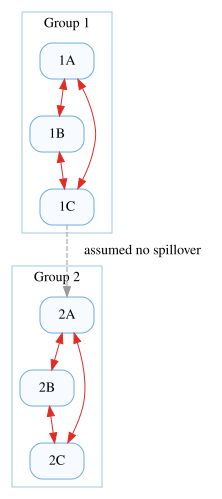

In [4]:
dot = Digraph("partial_interference", graph_attr={"rankdir": "TB"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

with dot.subgraph(name="cluster_1") as c:
    c.attr(label="Group 1", color="#9ecae1")
    for node in ["1A", "1B", "1C"]:
        c.node(node, node)
    c.edge("1A", "1B", dir="both", color="#de2d26")
    c.edge("1B", "1C", dir="both", color="#de2d26")
    c.edge("1A", "1C", dir="both", color="#de2d26")

with dot.subgraph(name="cluster_2") as c:
    c.attr(label="Group 2", color="#9ecae1")
    for node in ["2A", "2B", "2C"]:
        c.node(node, node)
    c.edge("2A", "2B", dir="both", color="#de2d26")
    c.edge("2B", "2C", dir="both", color="#de2d26")
    c.edge("2A", "2C", dir="both", color="#de2d26")

dot.edge("1C", "2A", style="dashed", color="#999999", label="assumed no spillover")
dot


Partial interference is a modeling assumption. It is useful only if the chosen groups actually contain the relevant spillover paths.


## 5. Estimands Under Interference

When interference exists, "the treatment effect" is not one number unless we define the exposure policy.

Hudgens and Halloran distinguish effects such as:


In [5]:
estimand_table = pd.DataFrame(
    [
        {
            "estimand": "Direct effect",
            "question": "What happens if I treat this unit, holding peer treatment saturation fixed?",
            "example": "Effect of training a salesperson when 50% of teammates are trained.",
        },
        {
            "estimand": "Indirect effect",
            "question": "What happens to an untreated unit when more peers are treated?",
            "example": "Effect on an untrained salesperson when more teammates receive training.",
        },
        {
            "estimand": "Total effect",
            "question": "What happens moving a unit from untreated in a low-saturation world to treated in a high-saturation world?",
            "example": "Effect of both training the person and increasing team training saturation.",
        },
        {
            "estimand": "Overall effect",
            "question": "What is the population average outcome under one treatment policy versus another?",
            "example": "Expected revenue if 80% of a team is trained versus 20%.",
        },
    ]
)

estimand_table


,estimand,question,example
0,Direct effect,"What happens if I treat this unit, holding pee...",Effect of training a salesperson when 50% of t...
1,Indirect effect,What happens to an untreated unit when more pe...,Effect on an untrained salesperson when more t...
2,Total effect,What happens moving a unit from untreated in a...,Effect of both training the person and increas...
3,Overall effect,What is the population average outcome under o...,Expected revenue if 80% of a team is trained v...


For a peer saturation level $\alpha$, a direct effect can be written:

$$
DE(\alpha) = E[Y_i(1, \alpha) - Y_i(0, \alpha)]
$$

An indirect effect among untreated units comparing saturation $\alpha_1$ and $\alpha_0$ can be written:

$$
IE(0; \alpha_1, \alpha_0) = E[Y_i(0, \alpha_1) - Y_i(0, \alpha_0)]
$$

The estimand must name both own treatment and peer exposure.


## 6. Simulation 1: Individual Randomization Misses Policy Spillovers

Suppose teams share knowledge. A treated worker gets a direct benefit, and every worker benefits when more teammates are treated.

The outcome model is:

$$
Y_{ig} =
\beta_0
+ \tau A_{ig}
+ \gamma \alpha_{ig}
+ b_g
+ \epsilon_{ig}
$$

where $\alpha_{ig}$ is the fraction of other team members treated.

If we randomize individuals independently at 50%, the treated-control difference mostly estimates the direct effect $\tau$, not the full policy effect of treating everyone.


In [6]:
rng = np.random.default_rng(4606)
n_groups = 140
group_size = 24
direct_effect = 1.5
spillover_effect = 2.2

def simulate_groups(assignments, rng, outcome_name="Y"):
    rows = []
    for group_id, a in enumerate(assignments):
        a = np.asarray(a)
        team_shock = rng.normal(0, 1.2)
        group_n = len(a)
        peer_saturation = (a.sum() - a) / (group_n - 1)
        baseline_skill = rng.normal(0, 1, size=group_n)
        y = (
            12
            + 0.8 * baseline_skill
            + direct_effect * a
            + spillover_effect * peer_saturation
            + team_shock
            + rng.normal(0, 1.5, size=group_n)
        )
        for i in range(group_n):
            rows.append(
                {
                    "group": group_id,
                    "unit": i,
                    "A": int(a[i]),
                    "peer_saturation": peer_saturation[i],
                    "baseline_skill": baseline_skill[i],
                    outcome_name: y[i],
                }
            )
    return pd.DataFrame(rows)


individual_assignments = [rng.binomial(1, 0.5, size=group_size) for _ in range(n_groups)]
df_individual = simulate_groups(individual_assignments, rng)

individual_naive = mean_difference(df_individual, "Y", "A")
individual_model = smf.ols("Y ~ A + peer_saturation + baseline_skill", data=df_individual).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_individual["group"]},
)

policy_effect_all_vs_none = direct_effect + spillover_effect

simulation_1_results = pd.DataFrame(
    {
        "Individual-randomization treated-control difference": individual_naive,
        "Regression direct effect controlling peer saturation": pd.Series(
            {
                "estimate": individual_model.params["A"],
                "std_error": individual_model.bse["A"],
                "ci_lower": individual_model.params["A"] - 1.96 * individual_model.bse["A"],
                "ci_upper": individual_model.params["A"] + 1.96 * individual_model.bse["A"],
            }
        ),
    }
).T

simulation_1_results


,estimate,std_error,ci_lower,ci_upper
Individual-randomization treated-control difference,1.517,0.074,1.372,1.663
Regression direct effect controlling peer saturation,1.540,0.074,1.396,1.684


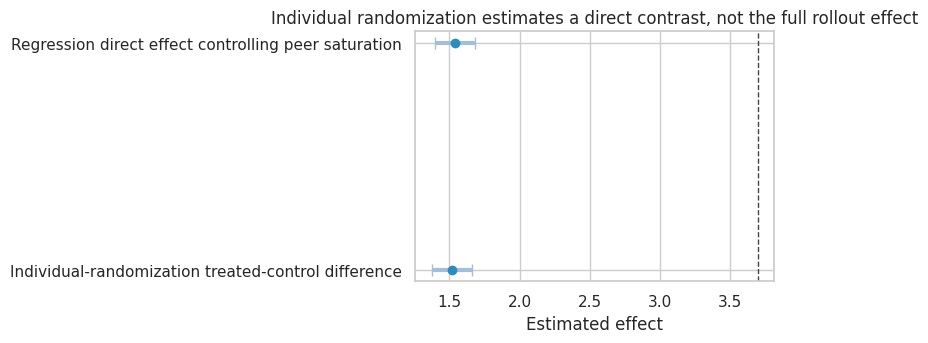

true_direct_effect                              1.500
true_spillover_effect_from_0_to_1               2.200
true_full_policy_effect_all_treated_vs_none     3.700
mean_peer_saturation_in_individual_experiment   0.505
dtype: float64

In [7]:
plot_coef_table(
    simulation_1_results,
    title="Individual randomization estimates a direct contrast, not the full rollout effect",
    xlabel="Estimated effect",
    reference=policy_effect_all_vs_none,
    figsize=(8, 3.6),
)
plt.show()

pd.Series(
    {
        "true_direct_effect": direct_effect,
        "true_spillover_effect_from_0_to_1": spillover_effect,
        "true_full_policy_effect_all_treated_vs_none": policy_effect_all_vs_none,
        "mean_peer_saturation_in_individual_experiment": df_individual["peer_saturation"].mean(),
    }
)


### Interpretation

The individual-randomized treated-control difference is close to the direct effect, because treated and control workers have similar expected peer saturation.

But the business rollout question might be:

> What happens if we train the whole team instead of nobody?

That effect includes both the direct effect and the peer-saturation effect. Individual randomization answers a narrower question.


## 7. Cluster Randomization Estimates a Different Policy Contrast

If we randomize whole groups, treated groups have peer saturation near 1 and control groups have peer saturation near 0. The treated-control contrast estimates the full policy contrast:

$$
Y_i(1, 1) - Y_i(0, 0)
$$

This may align better with full rollout, but it has fewer independent randomization units and typically less precision.


In [8]:
rng = np.random.default_rng(4607)
cluster_assignments = []
for _ in range(n_groups):
    group_treatment = rng.binomial(1, 0.5)
    cluster_assignments.append(np.repeat(group_treatment, group_size))

df_cluster = simulate_groups(cluster_assignments, rng)
cluster_naive = mean_difference(df_cluster, "Y", "A")
cluster_model = smf.ols("Y ~ A + baseline_skill", data=df_cluster).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_cluster["group"]},
)

cluster_results = pd.DataFrame(
    {
        "Cluster-randomized difference": cluster_naive,
        "Cluster-adjusted regression": pd.Series(
            {
                "estimate": cluster_model.params["A"],
                "std_error": cluster_model.bse["A"],
                "ci_lower": cluster_model.params["A"] - 1.96 * cluster_model.bse["A"],
                "ci_upper": cluster_model.params["A"] + 1.96 * cluster_model.bse["A"],
            }
        ),
    }
).T

combined_design_results = pd.concat(
    [
        simulation_1_results.assign(design="Individual randomization"),
        cluster_results.assign(design="Cluster randomization"),
    ]
)

cluster_results


,estimate,std_error,ci_lower,ci_upper
Cluster-randomized difference,3.841,0.074,3.696,3.986
Cluster-adjusted regression,3.835,0.231,3.382,4.289


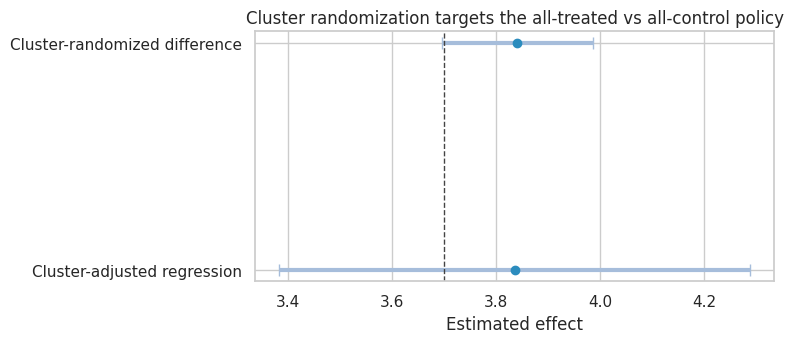

In [9]:
plot_coef_table(
    cluster_results,
    title="Cluster randomization targets the all-treated vs all-control policy",
    xlabel="Estimated effect",
    reference=policy_effect_all_vs_none,
    figsize=(8, 3.6),
)
plt.show()


Cluster randomization is not automatically better. It trades one problem for another:

- less contamination within clusters,
- better alignment with group-level rollout,
- fewer randomization units,
- more sensitivity to cluster imbalance,
- less ability to separate direct and spillover effects.


## 8. Randomized Saturation Designs

A randomized saturation design first assigns groups to treatment saturation levels, then assigns individuals within each group according to that saturation.

For example:

1. Randomize teams to 20%, 50%, or 80% training saturation.
2. Within each team, randomly choose the treated workers.

This creates variation in peer exposure and own treatment, allowing direct and spillover effects to be estimated.


In [10]:
rng = np.random.default_rng(4608)
saturation_levels = np.array([0.20, 0.50, 0.80])

saturation_assignments = []
group_saturations = []
for _ in range(n_groups):
    sat = rng.choice(saturation_levels)
    group_saturations.append(sat)
    saturation_assignments.append(rng.binomial(1, sat, size=group_size))

df_saturation = simulate_groups(saturation_assignments, rng)
df_saturation["assigned_saturation"] = np.repeat(group_saturations, group_size)

saturation_model = smf.ols(
    "Y ~ A + peer_saturation + baseline_skill",
    data=df_saturation,
).fit(cov_type="cluster", cov_kwds={"groups": df_saturation["group"]})

saturation_results = pd.DataFrame(
    {
        "Estimated direct effect": {
            "estimate": saturation_model.params["A"],
            "std_error": saturation_model.bse["A"],
            "ci_lower": saturation_model.params["A"] - 1.96 * saturation_model.bse["A"],
            "ci_upper": saturation_model.params["A"] + 1.96 * saturation_model.bse["A"],
        },
        "Estimated spillover effect per full saturation": {
            "estimate": saturation_model.params["peer_saturation"],
            "std_error": saturation_model.bse["peer_saturation"],
            "ci_lower": saturation_model.params["peer_saturation"] - 1.96 * saturation_model.bse["peer_saturation"],
            "ci_upper": saturation_model.params["peer_saturation"] + 1.96 * saturation_model.bse["peer_saturation"],
        },
    }
).T

saturation_results


,estimate,std_error,ci_lower,ci_upper
Estimated direct effect,1.465,0.055,1.358,1.572
Estimated spillover effect per full saturation,2.088,0.410,1.285,2.891


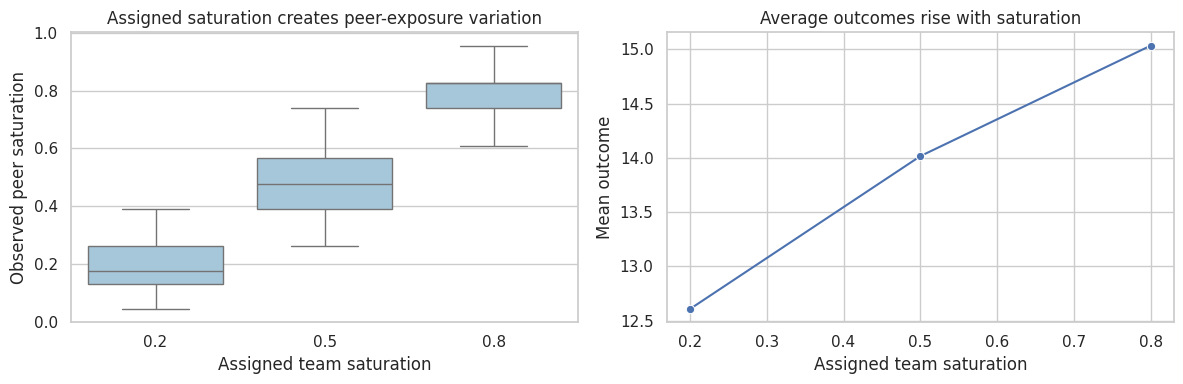

In [11]:
sat_summary = (
    df_saturation.groupby("assigned_saturation")
    .agg(
        n=("Y", "size"),
        observed_treatment_rate=("A", "mean"),
        mean_peer_saturation=("peer_saturation", "mean"),
        mean_outcome=("Y", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_saturation, x="assigned_saturation", y="peer_saturation", ax=axes[0], color="#9ecae1")
axes[0].set_title("Assigned saturation creates peer-exposure variation")
axes[0].set_xlabel("Assigned team saturation")
axes[0].set_ylabel("Observed peer saturation")

sns.lineplot(data=sat_summary, x="assigned_saturation", y="mean_outcome", marker="o", ax=axes[1])
axes[1].set_title("Average outcomes rise with saturation")
axes[1].set_xlabel("Assigned team saturation")
axes[1].set_ylabel("Mean outcome")

plt.tight_layout()
plt.show()


Randomized saturation designs are especially useful when the intervention will be deployed at different coverage levels. Baird et al. (2018) study optimal design choices for experiments under interference, focusing on randomized saturation designs.


## 9. Direct, Indirect, Total, and Overall Effects in the Simulation

Because we know the true data-generating process, we can compute clean estimands.


In [12]:
def potential_outcome(a, alpha, baseline_skill=0, team_shock=0):
    return 12 + 0.8 * baseline_skill + direct_effect * a + spillover_effect * alpha + team_shock


alpha_low = 0.20
alpha_high = 0.80

estimand_values = pd.DataFrame(
    [
        {
            "estimand": "Direct effect at alpha=0.20",
            "definition": "Y(1, 0.20) - Y(0, 0.20)",
            "value": potential_outcome(1, alpha_low) - potential_outcome(0, alpha_low),
        },
        {
            "estimand": "Direct effect at alpha=0.80",
            "definition": "Y(1, 0.80) - Y(0, 0.80)",
            "value": potential_outcome(1, alpha_high) - potential_outcome(0, alpha_high),
        },
        {
            "estimand": "Indirect effect among untreated",
            "definition": "Y(0, 0.80) - Y(0, 0.20)",
            "value": potential_outcome(0, alpha_high) - potential_outcome(0, alpha_low),
        },
        {
            "estimand": "Total effect",
            "definition": "Y(1, 0.80) - Y(0, 0.20)",
            "value": potential_outcome(1, alpha_high) - potential_outcome(0, alpha_low),
        },
        {
            "estimand": "Overall effect of high vs low saturation",
            "definition": "E[Y(A_alpha, alpha)] high policy - low policy",
            "value": (alpha_high - alpha_low) * direct_effect + (alpha_high - alpha_low) * spillover_effect,
        },
    ]
)

estimand_values


,estimand,definition,value
0,Direct effect at alpha=0.20,"Y(1, 0.20) - Y(0, 0.20)",1.500
1,Direct effect at alpha=0.80,"Y(1, 0.80) - Y(0, 0.80)",1.500
2,Indirect effect among untreated,"Y(0, 0.80) - Y(0, 0.20)",1.320
3,Total effect,"Y(1, 0.80) - Y(0, 0.20)",2.820
4,Overall effect of high vs low saturation,"E[Y(A_alpha, alpha)] high policy - low policy",2.220


The direct effect is constant in this simple model. In many real settings, direct effects also depend on peer saturation. For example, a seller ranking boost may be more valuable when few competitors are boosted and less valuable when many competitors are boosted.


## 10. Network Interference and Exposure Mappings

Partial interference assumes groups. Network interference assumes spillovers flow along edges.

The full assignment vector is too large to use directly, so analysts define an **exposure mapping**:

$$
g_i(A, G)
$$

which compresses the network assignment into an exposure condition for unit $i$.

Examples:

- own treatment only,
- number of treated neighbors,
- share of treated neighbors,
- at least one treated friend,
- all close friends treated,
- treated high-degree neighbors.


In [13]:
rng = np.random.default_rng(4610)
community_sizes = [55, 50, 60, 45]
prob_matrix = [
    [0.16, 0.015, 0.010, 0.010],
    [0.015, 0.15, 0.012, 0.010],
    [0.010, 0.012, 0.13, 0.018],
    [0.010, 0.010, 0.018, 0.17],
]

G = nx.stochastic_block_model(community_sizes, prob_matrix, seed=14)
communities = {}
start = 0
for c, size in enumerate(community_sizes):
    for node in range(start, start + size):
        communities[node] = c
    start += size

pos = nx.spring_layout(G, seed=21)
n_nodes = G.number_of_nodes()
network_df = pd.DataFrame(
    {
        "node": np.arange(n_nodes),
        "community": [communities[i] for i in range(n_nodes)],
        "degree": [G.degree(i) for i in range(n_nodes)],
    }
)

network_df["A"] = rng.binomial(1, 0.35, size=n_nodes)

treated_neighbors = []
neighbor_share = []
for node in range(n_nodes):
    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        treated_neighbors.append(0)
        neighbor_share.append(0)
    else:
        neighbor_treatments = network_df.loc[neighbors, "A"].to_numpy()
        treated_neighbors.append(neighbor_treatments.sum())
        neighbor_share.append(neighbor_treatments.mean())

network_df["treated_neighbors"] = treated_neighbors
network_df["neighbor_treatment_share"] = neighbor_share
network_df["any_treated_neighbor"] = (network_df["treated_neighbors"] > 0).astype(int)
network_df["high_exposure"] = (network_df["neighbor_treatment_share"] >= 0.5).astype(int)

network_df.head()


,node,community,degree,A,treated_neighbors,neighbor_treatment_share,any_treated_neighbor,high_exposure
0,0,0,12,0,7,0.583,1,1
1,1,0,11,1,3,0.273,1,0
2,2,0,9,1,4,0.444,1,0
3,3,0,12,0,5,0.417,1,0
4,4,0,9,0,2,0.222,1,0


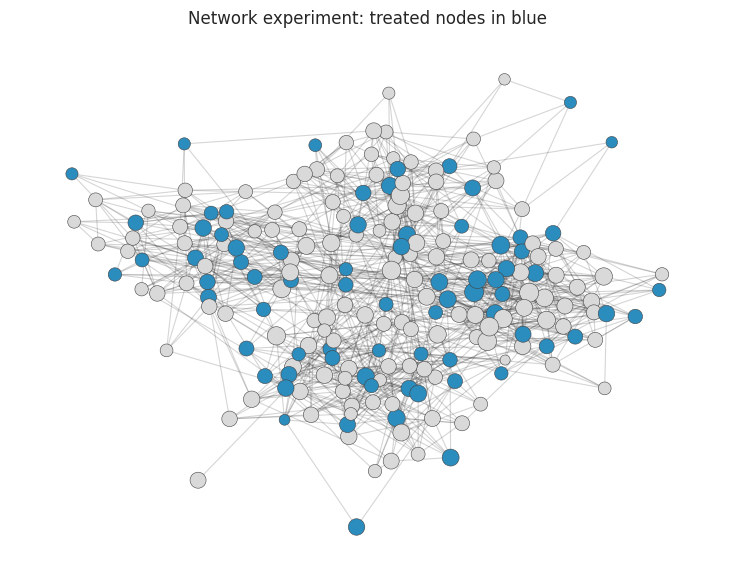

In [14]:
node_colors = np.where(network_df["A"] == 1, "#2b8cbe", "#d9d9d9")
node_sizes = 45 + 8 * network_df["degree"]

fig, ax = plt.subplots(figsize=(7.5, 6))
nx.draw_networkx_edges(G, pos, alpha=0.18, width=0.8, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, linewidths=0.4, edgecolors="#444444", ax=ax)
ax.set_title("Network experiment: treated nodes in blue")
ax.axis("off")
plt.tight_layout()
plt.show()


Aronow and Samii's framework emphasizes three ingredients:

1. the randomization design,
2. the exposure mapping,
3. the estimand defined using those exposures.

The exposure mapping is a scientific assumption. If it is wrong, the estimand may not match the real spillover process.


## 11. Simulating Network Spillovers

Now generate outcomes where both own treatment and treated-neighbor share matter:

$$
Y_i =
\beta_0
+ \tau A_i
+ \gamma \text{ShareTreatedNeighbors}_i
+ f(\text{degree}_i)
+ c_i
+ \epsilon_i
$$


In [15]:
rng = np.random.default_rng(4611)
network_direct = 1.0
network_spillover = 2.4
community_effects = rng.normal(0, 0.7, size=len(community_sizes))

network_df["Y"] = (
    8
    + network_direct * network_df["A"]
    + network_spillover * network_df["neighbor_treatment_share"]
    + 0.06 * network_df["degree"]
    + network_df["community"].map(dict(enumerate(community_effects)))
    + rng.normal(0, 1.2, size=n_nodes)
)

network_models = {
    "Naive own-treatment model": smf.ols("Y ~ A", data=network_df).fit(),
    "Exposure mapping: treated-neighbor share": smf.ols(
        "Y ~ A + neighbor_treatment_share + degree + C(community)",
        data=network_df,
    ).fit(),
    "Coarse exposure: any treated neighbor": smf.ols(
        "Y ~ A + any_treated_neighbor + degree + C(community)",
        data=network_df,
    ).fit(),
}

network_results = []
for name, model in network_models.items():
    for term in ["A", "neighbor_treatment_share", "any_treated_neighbor"]:
        if term in model.params:
            network_results.append(
                {
                    "model": name,
                    "term": term,
                    "estimate": model.params[term],
                    "std_error": model.bse[term],
                    "ci_lower": model.params[term] - 1.96 * model.bse[term],
                    "ci_upper": model.params[term] + 1.96 * model.bse[term],
                }
            )

network_results = pd.DataFrame(network_results)
network_results


,model,term,estimate,std_error,ci_lower,ci_upper
0,Naive own-treatment model,A,1.080,0.192,0.704,1.456
1,Exposure mapping: treated-neighbor share,A,1.032,0.190,0.661,1.404
2,Exposure mapping: treated-neighbor share,neighbor_treatment_share,1.637,0.618,0.426,2.848
3,Coarse exposure: any treated neighbor,A,1.093,0.189,0.722,1.464
4,Coarse exposure: any treated neighbor,any_treated_neighbor,1.309,0.486,0.355,2.262


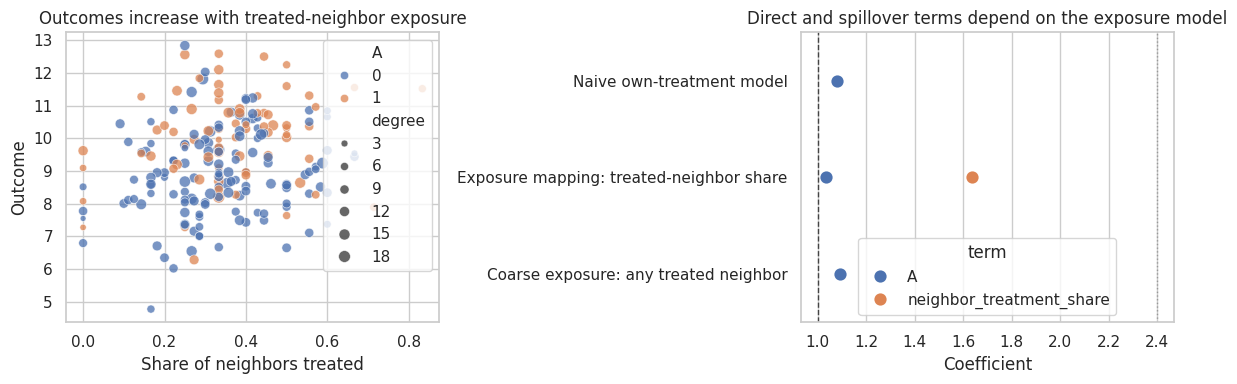

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=network_df,
    x="neighbor_treatment_share",
    y="Y",
    hue="A",
    size="degree",
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title("Outcomes increase with treated-neighbor exposure")
axes[0].set_xlabel("Share of neighbors treated")
axes[0].set_ylabel("Outcome")

plot_df = network_results.loc[network_results["term"].isin(["A", "neighbor_treatment_share"])].copy()
sns.pointplot(data=plot_df, y="model", x="estimate", hue="term", join=False, ax=axes[1])
axes[1].axvline(network_direct, color="#444444", linestyle="--", linewidth=1)
axes[1].axvline(network_spillover, color="#999999", linestyle=":", linewidth=1)
axes[1].set_title("Direct and spillover terms depend on the exposure model")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


The naive own-treatment model absorbs some spillover structure into noise or bias. The model with treated-neighbor share is aligned with the true exposure process, so it separates direct and spillover effects better.

The coarse "any treated neighbor" exposure is interpretable but loses information. Sometimes that is acceptable; sometimes it hides dose-response behavior.


## 12. Exposure Conditions and Effective Sample Size

Exposure mappings can create rare exposure conditions. Rare exposures are hard to estimate.

For example, in a sparse network, "all neighbors treated" may be extremely rare. In a dense network, "no treated neighbors" may be rare.


In [17]:
network_df["exposure_label"] = pd.cut(
    network_df["neighbor_treatment_share"],
    bins=[-0.01, 0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["none", "low", "medium", "high", "all"],
)

exposure_counts = (
    network_df.groupby(["A", "exposure_label"], observed=False)
    .size()
    .reset_index(name="n")
)

exposure_counts


,A,exposure_label,n
0,0,none,4
1,0,low,38
2,0,medium,77
3,0,high,17
4,0,all,0
5,1,none,4
6,1,low,12
7,1,medium,49
8,1,high,8
9,1,all,1


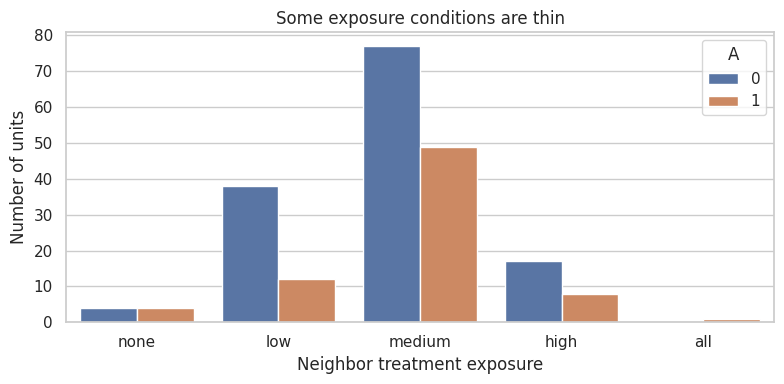

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=exposure_counts, x="exposure_label", y="n", hue="A", ax=ax)
ax.set_title("Some exposure conditions are thin")
ax.set_xlabel("Neighbor treatment exposure")
ax.set_ylabel("Number of units")
plt.tight_layout()
plt.show()


This is the network analogue of positivity. A design can be randomized and still provide little information about some exposures.


## 13. Graph-Cluster Randomization

Ugander et al. (2013) discuss graph-cluster randomization for online experiments with network spillovers. The broad idea is:

1. partition the network into clusters,
2. randomize clusters rather than individual nodes,
3. increase the probability that a node's neighbors receive the same assignment.

This improves exposure to coherent treatment worlds, though it reduces the number of independent randomization units.


In [19]:
rng = np.random.default_rng(4612)

network_df["A_cluster"] = 0
for community in network_df["community"].unique():
    community_assignment = rng.binomial(1, 0.5)
    network_df.loc[network_df["community"] == community, "A_cluster"] = community_assignment

cluster_neighbor_share = []
for node in range(n_nodes):
    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        cluster_neighbor_share.append(0)
    else:
        cluster_neighbor_share.append(network_df.loc[neighbors, "A_cluster"].mean())
network_df["neighbor_share_cluster_randomized"] = cluster_neighbor_share

exposure_comparison = pd.DataFrame(
    {
        "design": ["Individual randomization"] * n_nodes + ["Graph-cluster randomization"] * n_nodes,
        "neighbor_treatment_share": list(network_df["neighbor_treatment_share"]) + list(network_df["neighbor_share_cluster_randomized"]),
    }
)

exposure_comparison.groupby("design")["neighbor_treatment_share"].describe()


,count,mean,std,min,25%,50%,75%,max
design,,,,,,,,
Graph-cluster randomization,210.000,0.731,0.351,0.000,0.357,0.900,1.000,1.000
Individual randomization,210.000,0.344,0.149,0.000,0.250,0.333,0.435,0.833


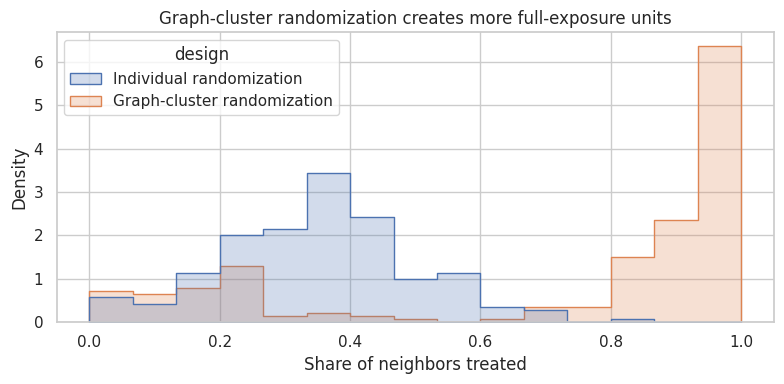

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=exposure_comparison,
    x="neighbor_treatment_share",
    hue="design",
    bins=15,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_title("Graph-cluster randomization creates more full-exposure units")
ax.set_xlabel("Share of neighbors treated")
plt.tight_layout()
plt.show()


Graph-cluster randomization is useful when the relevant policy is closer to "communities experience the same product world" than "isolated individuals receive treatment."

The price is variance: fewer clusters means fewer independent assignment units.


## 14. Marketplace Spillovers: Reallocation vs Creation

Marketplaces often have interference even when units are not socially connected.

If a ranking treatment boosts one seller, it may:

- create new demand,
- reallocate demand from other sellers,
- change buyer search effort,
- change inventory availability,
- alter prices or congestion.

An item-level experiment may estimate local reallocation, not platform-level lift.


In [21]:
rng = np.random.default_rng(4614)
n_searches = 6000
items_per_search = 8

search_rows = []
for search_id in range(n_searches):
    base_demand = rng.gamma(shape=3.5, scale=1.2)
    item_quality = rng.normal(0, 1, size=items_per_search)
    treatment = rng.binomial(1, 0.5, size=items_per_search)
    
    # Ranking boost changes share within the search results. It creates only modest new total demand.
    attractiveness_control = np.exp(0.55 * item_quality)
    attractiveness_treated = np.exp(0.55 * item_quality + 0.65 * treatment)
    total_market_expansion = 1 + 0.04 * treatment.mean()
    
    shares_control_world = attractiveness_control / attractiveness_control.sum()
    shares_observed_world = attractiveness_treated / attractiveness_treated.sum()
    
    purchases_control_world = base_demand * shares_control_world
    purchases_observed = base_demand * total_market_expansion * shares_observed_world
    
    for item in range(items_per_search):
        search_rows.append(
            {
                "search_id": search_id,
                "item": item,
                "quality": item_quality[item],
                "A": treatment[item],
                "Y_observed": purchases_observed[item] + rng.normal(0, 0.05),
                "Y_control_world": purchases_control_world[item],
                "treated_share_in_search": treatment.mean(),
            }
        )

market = pd.DataFrame(search_rows)

item_level_estimate = mean_difference(market, "Y_observed", "A")
search_level = market.groupby("search_id", as_index=False).agg(
    total_observed=("Y_observed", "sum"),
    treated_share=("A", "mean"),
)

market_summary = pd.Series(
    {
        "item_level_treated_control_difference": item_level_estimate["estimate"],
        "mean_total_purchases_observed": search_level["total_observed"].mean(),
        "mean_treated_share_per_search": search_level["treated_share"].mean(),
        "approx_total_market_expansion_at_50pct_treatment": 0.04 * search_level["treated_share"].mean(),
    }
)

market_summary


item_level_treated_control_difference              0.283
mean_total_purchases_observed                      4.272
mean_treated_share_per_search                      0.503
approx_total_market_expansion_at_50pct_treatment   0.020
dtype: float64

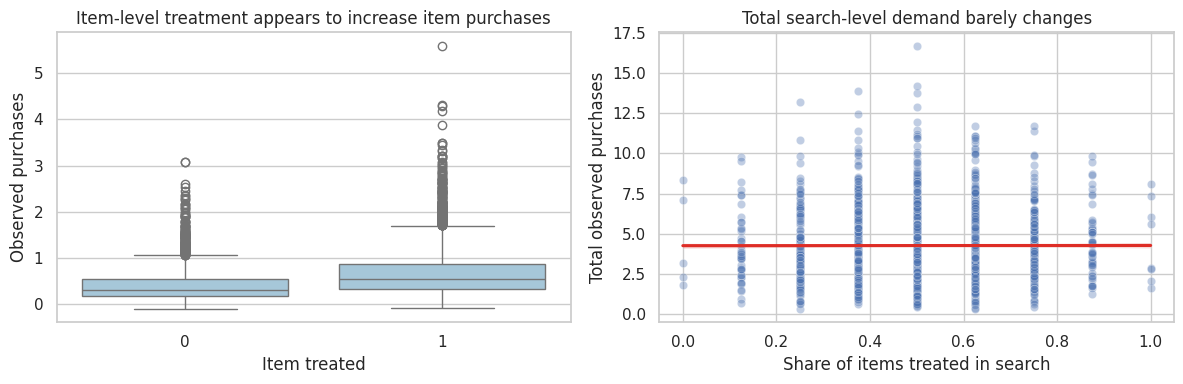

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=market.sample(8000, random_state=19), x="A", y="Y_observed", ax=axes[0], color="#9ecae1")
axes[0].set_title("Item-level treatment appears to increase item purchases")
axes[0].set_xlabel("Item treated")
axes[0].set_ylabel("Observed purchases")

sns.scatterplot(data=search_level.sample(1500, random_state=20), x="treated_share", y="total_observed", alpha=0.35, ax=axes[1])
sns.regplot(data=search_level, x="treated_share", y="total_observed", scatter=False, ax=axes[1], color="#de2d26")
axes[1].set_title("Total search-level demand barely changes")
axes[1].set_xlabel("Share of items treated in search")
axes[1].set_ylabel("Total observed purchases")

plt.tight_layout()
plt.show()


### Interpretation

At the item level, treated items look better because the ranking boost reallocates attention toward them. But total search-level demand barely changes. A platform decision should care about market-level outcomes, not only treated item outcomes.

This is why marketplace experiments often randomize at higher levels:

- query,
- user,
- geography,
- market,
- time block,
- supply-side cluster.

The right unit depends on the interference path.


## 15. Choosing a Design Under Interference

The design should follow the interference mechanism.


In [23]:
design_guide = pd.DataFrame(
    [
        {
            "interference pattern": "No meaningful spillovers",
            "reasonable design": "Individual randomization",
            "main estimand": "Unit-level direct effect",
            "diagnostic": "Check pre-specified channels where controls could be exposed.",
        },
        {
            "interference pattern": "Spillovers within teams/classes/stores",
            "reasonable design": "Cluster randomization",
            "main estimand": "Group-level rollout effect",
            "diagnostic": "Cluster-level balance and enough independent clusters.",
        },
        {
            "interference pattern": "Spillovers vary by treatment saturation",
            "reasonable design": "Randomized saturation design",
            "main estimand": "Direct and indirect effects by saturation",
            "diagnostic": "Variation in own treatment and peer saturation.",
        },
        {
            "interference pattern": "Network spillovers",
            "reasonable design": "Network exposure design or graph-cluster randomization",
            "main estimand": "Effect by exposure condition",
            "diagnostic": "Exposure mapping, exposure probabilities, network measurement.",
        },
        {
            "interference pattern": "Marketplace equilibrium",
            "reasonable design": "Market/query/geography/time-level randomization",
            "main estimand": "Policy effect on total market outcomes",
            "diagnostic": "Reallocation metrics and market-level KPIs.",
        },
    ]
)

design_guide


,interference pattern,reasonable design,main estimand,diagnostic
0,No meaningful spillovers,Individual randomization,Unit-level direct effect,Check pre-specified channels where controls co...
1,Spillovers within teams/classes/stores,Cluster randomization,Group-level rollout effect,Cluster-level balance and enough independent c...
2,Spillovers vary by treatment saturation,Randomized saturation design,Direct and indirect effects by saturation,Variation in own treatment and peer saturation.
3,Network spillovers,Network exposure design or graph-cluster rando...,Effect by exposure condition,"Exposure mapping, exposure probabilities, netw..."
4,Marketplace equilibrium,Market/query/geography/time-level randomization,Policy effect on total market outcomes,Reallocation metrics and market-level KPIs.


## 16. Diagnostics Before Running the Experiment

Before launching an experiment, ask:


In [24]:
diagnostic_questions = pd.DataFrame(
    [
        {
            "question": "Can treated units affect control outcomes?",
            "example": "Treated sellers compete with control sellers for the same buyers.",
        },
        {
            "question": "What is the natural spillover boundary?",
            "example": "Team, classroom, search query, market, geography, network community.",
        },
        {
            "question": "Is the planned randomization unit aligned with the decision?",
            "example": "A full rollout changes all listings, not isolated listings.",
        },
        {
            "question": "What exposure mapping is plausible?",
            "example": "Share of treated neighbors, any treated teammate, treated market share.",
        },
        {
            "question": "Will important exposure conditions have enough units?",
            "example": "Enough untreated users with many treated friends?",
        },
        {
            "question": "What metric detects reallocation?",
            "example": "Total query purchases, not only purchases for boosted items.",
        },
        {
            "question": "What is the independent assignment unit for uncertainty?",
            "example": "Clusters or markets, not individual rows inside a treated market.",
        },
    ]
)

diagnostic_questions


,question,example
0,Can treated units affect control outcomes?,Treated sellers compete with control sellers f...
1,What is the natural spillover boundary?,"Team, classroom, search query, market, geograp..."
2,Is the planned randomization unit aligned with...,"A full rollout changes all listings, not isola..."
3,What exposure mapping is plausible?,"Share of treated neighbors, any treated teamma..."
4,Will important exposure conditions have enough...,Enough untreated users with many treated friends?
5,What metric detects reallocation?,"Total query purchases, not only purchases for ..."
6,What is the independent assignment unit for un...,"Clusters or markets, not individual rows insid..."


## 17. Decision Memo Example

Here is a concise interference memo for an industry experiment.


In [25]:
memo = '''
### Interference Memo

**Decision.** Decide whether to launch a new ranking feature in a two-sided marketplace.

**Why standard A/B testing is risky.** Treating individual listings can change impressions and purchases for untreated listings in the same search results. This violates the no-interference assumption.

**Likely spillover path.** Buyer attention is limited within each search result page. Boosted listings may win attention from control listings rather than increasing total buyer demand.

**Primary estimand.** Policy effect of launching the ranking feature on total query-level purchases, buyer conversion, seller concentration, and platform revenue.

**Recommended design.**

- Randomize at the query or market level rather than the listing level.
- Track total query-level outcomes, not only treated-listing outcomes.
- Include seller-side concentration and displacement metrics.
- Use cluster-robust uncertainty at the randomization unit.

**Secondary analysis.**

- Estimate direct listing effects and spillover effects separately using exposure mappings.
- Compare high-treatment and low-treatment saturation cells if a randomized saturation design is feasible.

**Decision rule.** Launch only if total market outcomes improve without unacceptable seller displacement.
'''.strip()

display(Markdown(memo))


### Interference Memo

**Decision.** Decide whether to launch a new ranking feature in a two-sided marketplace.

**Why standard A/B testing is risky.** Treating individual listings can change impressions and purchases for untreated listings in the same search results. This violates the no-interference assumption.

**Likely spillover path.** Buyer attention is limited within each search result page. Boosted listings may win attention from control listings rather than increasing total buyer demand.

**Primary estimand.** Policy effect of launching the ranking feature on total query-level purchases, buyer conversion, seller concentration, and platform revenue.

**Recommended design.**

- Randomize at the query or market level rather than the listing level.
- Track total query-level outcomes, not only treated-listing outcomes.
- Include seller-side concentration and displacement metrics.
- Use cluster-robust uncertainty at the randomization unit.

**Secondary analysis.**

- Estimate direct listing effects and spillover effects separately using exposure mappings.
- Compare high-treatment and low-treatment saturation cells if a randomized saturation design is feasible.

**Decision rule.** Launch only if total market outcomes improve without unacceptable seller displacement.

## 18. Common Failure Modes

1. Calling an individual-level A/B test a policy estimate when controls were exposed through peers or competition.
2. Measuring only treated-unit outcomes when the intervention reallocates outcomes from untreated units.
3. Ignoring the cluster or network assignment unit when calculating uncertainty.
4. Defining exposure after seeing the results.
5. Using clusters that do not match actual spillover boundaries.
6. Assuming no interference because the product does not look "social."
7. Treating graph-cluster randomization as a cure-all while ignoring reduced power.
8. Forgetting that full rollout can change equilibrium behavior.


## 19. Exercises

1. In Simulation 1, set the spillover effect to zero. Compare individual and cluster randomization.
2. Increase the spillover effect to 5.0. How much does individual randomization miss the all-treated policy effect?
3. In the randomized saturation design, add a treatment-by-peer-saturation interaction. Which estimands now depend on saturation?
4. In the network simulation, redefine exposure as "at least two treated neighbors." How many units are in each exposure condition?
5. In the marketplace simulation, increase total market expansion from 4% to 25%. When does the listing-level result become more aligned with platform lift?
6. Pick a real experiment from your own work. Draw the interference graph or spillover boundary before choosing the randomization unit.


## 20. Key Takeaways

- The no-interference assumption says one unit's outcome does not depend on other units' treatment assignments.
- Under interference, the estimand must specify own treatment and peer or market exposure.
- Individual randomization can estimate direct effects while missing spillover and full-rollout policy effects.
- Cluster randomization can better match group-level rollout, but it reduces the number of independent assignment units.
- Randomized saturation designs help estimate direct and indirect effects.
- Network experiments require exposure mappings and exposure probability diagnostics.
- Marketplace experiments must distinguish market expansion from reallocation.
- The best design starts with the spillover mechanism, not with the default randomization tool.


## References

Aronow, P. M., & Samii, C. (2017). Estimating average causal effects under general interference, with application to a social network experiment. *The Annals of Applied Statistics, 11*(4), 1912-1947. https://doi.org/10.1214/16-AOAS1005

Baird, S., Bohren, J. A., McIntosh, C., & Ozler, B. (2018). Optimal design of experiments in the presence of interference. *The Review of Economics and Statistics, 100*(5), 844-860. https://doi.org/10.1162/rest_a_00716

Hudgens, M. G., & Halloran, M. E. (2008). Toward causal inference with interference. *Journal of the American Statistical Association, 103*(482), 832-842. https://doi.org/10.1198/016214508000000292

Sobel, M. E. (2006). What do randomized studies of housing mobility demonstrate? Causal inference in the face of interference. *Journal of the American Statistical Association, 101*(476), 1398-1407. https://doi.org/10.1198/016214506000000636

Toulis, P., & Kao, E. (2013). Estimation of causal peer influence effects. *Proceedings of the 30th International Conference on Machine Learning*, 1489-1497. http://proceedings.mlr.press/v28/toulis13.html

Ugander, J., Karrer, B., Backstrom, L., & Kleinberg, J. (2013). Graph cluster randomization: Network exposure to multiple universes. *Proceedings of the 19th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 329-337. https://doi.org/10.1145/2487575.2487695
